# Raman Spectra Validation - Quantitative Overlay

This notebook visualizes the overall alignment between the **Experimental Raman Spectrum** and the **DFT Simulated Spectrum**, and marks all **51 matched peaks** clearly without overlaps. A summary results box is provided on the right.

C:\Users\sukes\AppData\Local\Temp\ipykernel_24260\4183668955.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


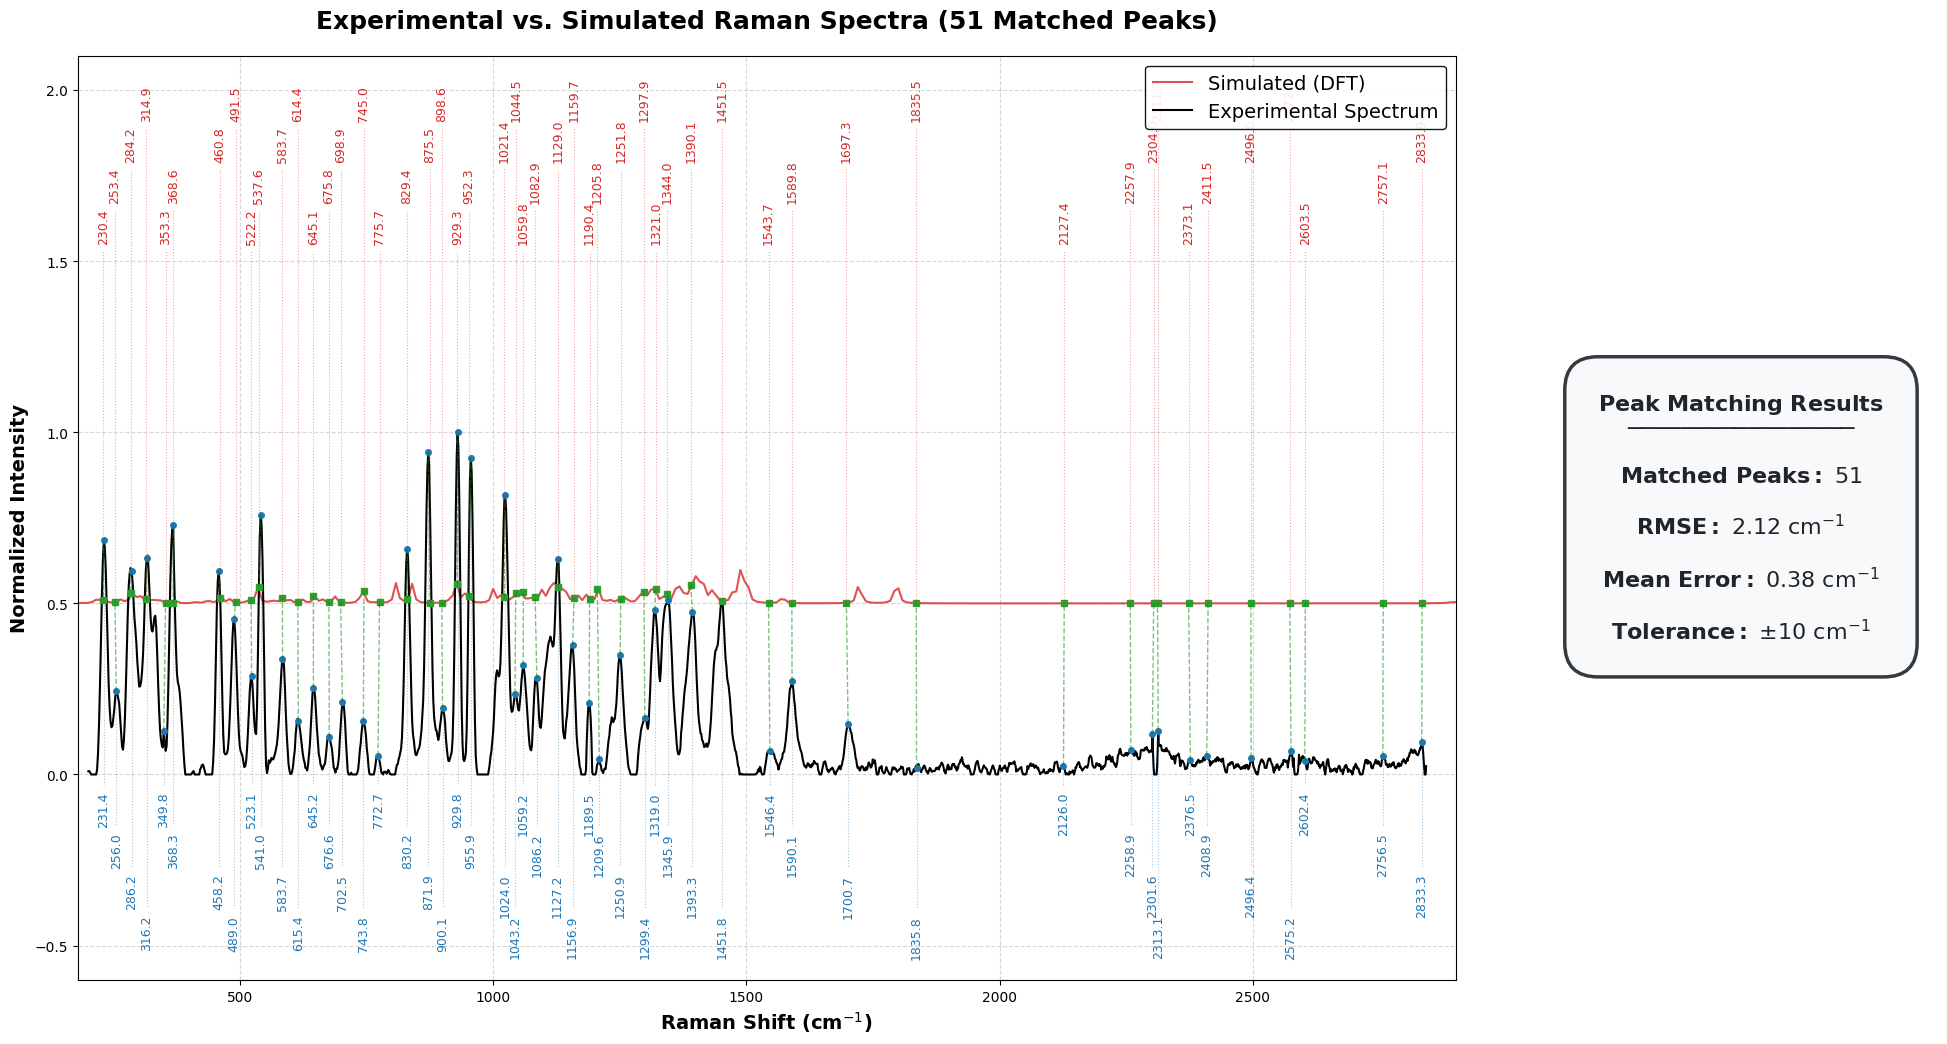

Plot successfully saved to: 'output_figures/fig13_all_51_peaks_Validation.png'


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os

# Ensure output directory exists
os.makedirs('output_figures', exist_ok=True)

# 1. Load Data
exp_df = pd.read_csv('output_figures/processed_sec-25_power-80_i-2.csv')
exp_x = exp_df.iloc[:, 0].values
exp_y = exp_df.iloc[:, 1].values

sim_df = pd.read_excel('simdata.xlsx')
sim_x = sim_df['X'].values
sim_y = sim_df['Y'].values

matches_df = pd.read_csv('output_figures/peak_matching_table.csv')
matched_exp = matches_df['Experimental (cm⁻¹)'].values
matched_sim = matches_df['DFT Simulated (cm⁻¹)'].values

# 2. Data Processing & Normalization
# Normalize simulation to 0-1 range to match experimental data scale
sim_y = (sim_y - sim_y.min()) / (sim_y.max() - sim_y.min())
# Scale up the simulated peaks slightly so they are as prominent as the experimental peaks visually
sim_y = sim_y * 1.5

# Offset for visual clarity between the two spectra
offset = 0.5
sim_y_offset = sim_y + offset

# 3. Plot Configuration
fig = plt.figure(figsize=(24, 12)) # Very wide figure to fit 51 peaks properly
gs = fig.add_gridspec(1, 2, width_ratios=[3.5, 1], wspace=0.1)

ax_main = fig.add_subplot(gs[0, 0])
ax_text = fig.add_subplot(gs[0, 1])

# --- LEFT SIDE: Overlay Plot ---
ax_main.plot(sim_x, sim_y_offset, color='#d62728', label='Simulated (DFT)', alpha=0.8, linewidth=1.5)
ax_main.plot(exp_x, exp_y, color='black', label='Experimental Spectrum', linewidth=1.5)

# Mark all 51 matched peaks
for i in range(len(matched_exp)):
    e_val = matched_exp[i]
    s_val = matched_sim[i]
    
    # Find highest intensity Point for the match
    e_idx = (np.abs(exp_x - e_val)).argmin()
    ey_val = exp_y[e_idx]
    
    s_idx = (np.abs(sim_x - s_val)).argmin()
    sy_val = sim_y_offset[s_idx]
    
    # Plot the exact peak points
    ax_main.plot(e_val, ey_val, marker='o', color='#1f77b4', markersize=4)
    ax_main.plot(s_val, sy_val, marker='s', color='#2ca02c', markersize=4)
    
    # Draw a dashed line connecting the matched peaks between spectra
    ax_main.plot([e_val, s_val], [ey_val, sy_val], color='green', linestyle='--', linewidth=1, alpha=0.5)
    
    # Alternate text heights to prevent overlapping (4 different levels)
    level_exp = 0.05 + (i % 4) * 0.12
    ax_main.plot([e_val, e_val], [ey_val, -level_exp + 0.02], color='#1f77b4', linewidth=0.8, alpha=0.4, linestyle=':')
    ax_main.text(e_val, -level_exp, f"{e_val:.1f}", fontsize=9, color='#1f77b4', ha='center', va='top', rotation=90)

    level_sim = 0.05 + (i % 4) * 0.12
    max_sim = 1.5
    ax_main.plot([s_val, s_val], [sy_val, max_sim + level_sim - 0.02], color='#d62728', linewidth=0.8, alpha=0.4, linestyle=':')
    ax_main.text(s_val, max_sim + level_sim, f"{s_val:.1f}", fontsize=9, color='#d62728', ha='center', va='bottom', rotation=90)

ax_main.set_xlabel('Raman Shift (cm$^{-1}$)', fontsize=14, fontweight='bold')
ax_main.set_ylabel('Normalized Intensity', fontsize=14, fontweight='bold')
ax_main.set_xlim(180, 2900)
ax_main.set_ylim(-0.6, 2.1)
ax_main.legend(loc='upper right', fontsize=14, framealpha=0.9, edgecolor='black', shadow=False)
ax_main.grid(True, linestyle='--', alpha=0.5)
ax_main.set_title('Experimental vs. Simulated Raman Spectra (51 Matched Peaks)', fontsize=18, fontweight='bold', pad=20)

# --- RIGHT SIDE: Results Box ---
ax_text.axis('off')

box_text = (
    "$\\mathbf{Peak\\ Matching\\ Results}$\n"
    "─────────────────\n\n"
    "$\\mathbf{Matched\\ Peaks:}$ 51\n\n"
    "$\\mathbf{RMSE:}$ 2.12 cm$^{-1}$\n\n"
    "$\\mathbf{Mean\\ Error:}$ 0.38 cm$^{-1}$\n\n"
    "$\\mathbf{Tolerance:}$ ±10 cm$^{-1}$"
)

bbox_props = dict(boxstyle="round,pad=1.5", fc="#f8f9fa", ec="#343a40", lw=2.5)

ax_text.text(0.5, 0.5, box_text, 
             ha='center', va='center', 
             fontsize=16, 
             bbox=bbox_props, 
             color='#212529',
             transform=ax_text.transAxes)

plt.tight_layout()
plt.savefig('output_figures/fig13_all_51_peaks_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("Plot successfully saved to: 'output_figures/fig13_all_51_peaks_Validation.png'")
